In [9]:
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import umap
import torch
import anndata as ad
from scipy.sparse import csr_matrix
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from mmidas.utils.config_tools import get_paths
from mmidas.utils.batch_removal import align_query
from mmidas.vaegan import vae_gan
from mmidas.utils.data_tools import load_data
from mmidas.utils.augmentation import get_loader as aug_loader

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
toml_file = 'pyproject.toml'
config = get_paths(toml_file=toml_file)
Dbh_file = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['Dbh_file']
Retroseq_file = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['Retroseq_file']
Dbh_Retroseq_file = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['Dbh_Retroseq_nobr_file']
selected_files = [Dbh_file, Retroseq_file]

/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/pyproject.toml
Getting files directories belong to data...
Getting files directories belong to models...


In [3]:
device = torch.device("cpu")
aug_path = config['paths']['main_dir'] / config['paths']['models']
aug_file = aug_path / config['models']['augmenter_Dbh_Retroseq_nobr']
aug_vaegan = vae_gan(saving_folder=aug_path, device=device)
aug_vaegan.load_model(aug_file)
augmenter = aug_vaegan.netA

---> Using CPU!
Load the pre-trained augmenter model - /allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/models/RNA_augmenter_Dbh_Retroseq_nobr_2025-02-06-15-00-51.pth


In [5]:
Dbh_Retroseq_data = load_data(file=Dbh_Retroseq_file)
x_Dbh = Dbh_Retroseq_data['log1p'][Dbh_Retroseq_data['dataset'] == 'Dbh']
x_Retroseq = Dbh_Retroseq_data['log1p'][Dbh_Retroseq_data['dataset'] == 'Retroseq']

Number of cells: 5133, Number of genes: 1841


In [ ]:
data_loader = aug_loader(x=x_Retroseq, batch_size=256, training=False)

aug_samples = []
for _ in range(x_Dbh.shape[0] // x_Retroseq.shape[0]):
    aug_samples.append(aug_vaegan.sample_generator(dataloader=data_loader, noise=True, scale=0.1, exclude_zeros=False))
aug_samples = np.concatenate(aug_samples, axis=0)

print(f'Original shape: {x_Retroseq.shape}, Augmented shape: {aug_samples.shape}')

Dataloader for augmentation created!
Original shape: (4608, 1841), Augmented shape: (4200, 1841)


/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/Temp/ipykernel_29320/363952319.py:7: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = aug_samples_adata.concatenate(original_data_adata)


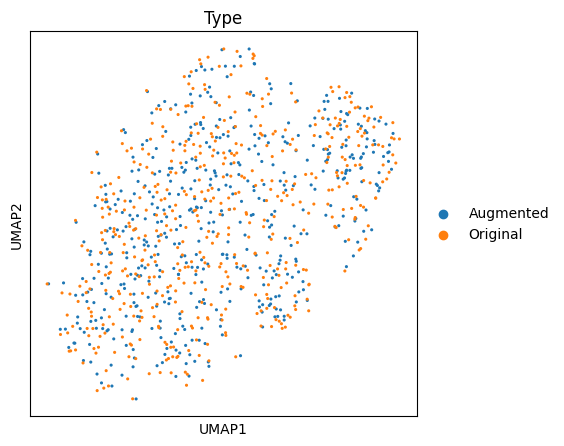

In [41]:
# Convert original_data to AnnData object
original_data_adata = ad.AnnData(X=x_Retroseq[np.random.choice(x_Retroseq.shape[0], 500, replace=False)])
original_data_adata.obs['Type'] = 'Original'
aug_samples_adata = ad.AnnData(X=x_Retroseq[np.random.choice(x_Retroseq.shape[0], 500, replace=False)])
aug_samples_adata.obs['Type'] = 'Augmented'

adata = aug_samples_adata.concatenate(original_data_adata)

sc.pp.neighbors(adata, use_rep='X', random_state=100)
sc.tl.umap(adata)
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
sc.pl.umap(adata, color='Type', ax=axs, size=20, alpha=1)

In [6]:
ref_data = []
for i_f, file in enumerate([Dbh_file]):
    adata = sc.read_h5ad(file)
    genes = adata.var.index.values
    g_index = [np.where(genes == g)[0][0] for g in updated_hvgs]
    ref_data.append(adata.X[:, g_index].toarray())

ref_data = np.vstack(ref_data)

andata = sc.read_h5ad(Retroseq_file)
g_index = [np.where(andata.var.index.values == g)[0][0] for g in updated_hvgs]
query_data = andata.X[:, g_index].toarray()


In [7]:
# build a new dataset with the corrected data
data_ = np.concatenate((ref_data, query_data), axis=0)
print(f"Number of cells in the new dataset: {data_.shape[0]}, number of genes: {data_.shape[1]}")

annos, len_data = [], []
for ff in selected_files:
    adata_ = sc.read_h5ad(ff)
    annos.append(adata_.obs)
    len_data.append(adata_.X.shape[0])
    
# mutual_keys = set.intersection(*(set(anno.keys()) for anno in annos))
mutual_keys = set.intersection(*(set(anno.keys()) for anno in annos))

# concatenate dictiornaies with common keys
mix_data = {key: np.concatenate((annos[0][key], annos[1][key]), axis=0) for key in mutual_keys}
mix_data = pd.DataFrame(mix_data)
mix_data['sample_id'] = np.concatenate((annos[0]['sample_id'], annos[1]['sample_name']), axis=0)
mix_data['external_donor_name'] = np.concatenate((annos[0]['external_donor_name'], annos[1]['exp_component_name']), axis=0)
mix_data['sex'] = np.concatenate((annos[0]['sex'], annos[1]['gender']), axis=0)
mix_data['age'] = np.concatenate((np.array([' '] * len_data[0]), annos[1]['age']), axis=0)
mix_data['batch'] = np.concatenate((annos[0]['batch'], np.array([' '] * len_data[1])), axis=0)
mix_data['injection_target'] = np.concatenate((np.array([' '] * len_data[0]), annos[1]['injection_target']), axis=0)
mix_data['dataset'] = np.concatenate((np.array(['Dbh'] * len_data[0]), np.array(['Retroseq'] * len_data[1])), axis=0)
mix_data['sex'] = np.array([s.split(';')[0] for s in mix_data['sex']])

andata_ = sc.AnnData(X=csr_matrix(data_), obs=pd.DataFrame(mix_data), var={'gene': updated_hvgs})
andata_.write(config['paths']['main_dir'] / config['paths']['data_path'] / 'Dbh_Retroseq_nobr.h5ad')

Number of cells in the new dataset: 5133, number of genes: 1841


/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [50]:
genes = []
X = []
for i_f, file in enumerate(selected_files):
    adata = sc.read_h5ad(file)
    genes.append(adata.var.index.values)

all_genes = np.array(list(set(genes[0]).intersection(*genes[1:])))
for i_f, file in enumerate(selected_files):
    adata = sc.read_h5ad(file)
    genes = adata.var.index.values
    g_index = [np.where(genes == g)[0][0] for g in all_genes]
    X.append(adata.X[:, g_index].toarray())
    
X = np.vstack(X)
g_std = np.std(X, axis=0)
hvgs_indx = np.argsort(g_std)[::-1][:2000]
hvgs_2 = all_genes[hvgs_indx]

Minimum std: 0.3900213944368793, Maximum std: 3.318265499277989, num of cells: 4608
Minimum std: 1.3903367111562717, Maximum std: 3.3436737462471378, num of cells: 3715
Minimum std: 0.15074957753344626, Maximum std: 2.8793581141876308, num of cells: 525


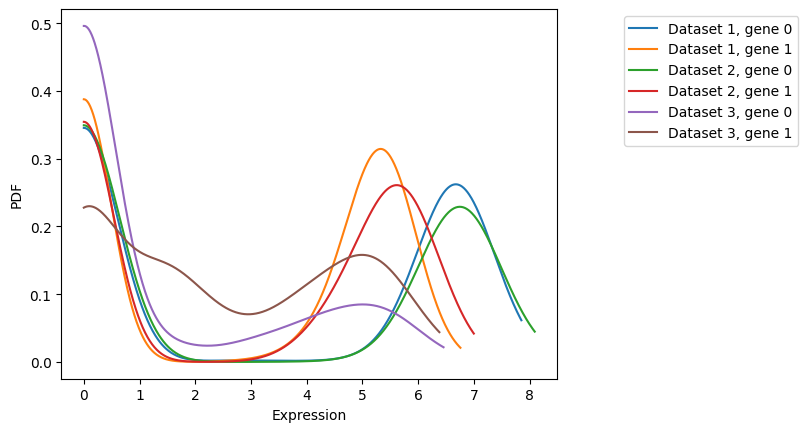

In [74]:
plt.Figure()
for i_f, file in enumerate(selected_files):
    adata = sc.read_h5ad(file)
    genes = adata.var.index.values
    g_index = [np.where(genes == g)[0][0] for g in hvgs_2]
    X = adata.X[:, g_index].toarray()
    g_std = np.std(X, axis=0)
    print(f'Minimum std: {np.min(g_std)}, Maximum std: {np.max(g_std)}, num of cells: {X.shape[0]}')
    for ii in range(2):
        kde = gaussian_kde(X[:, ii])
        x = np.linspace(min(X[:, ii]), max(X[:, ii]), 1000)  # Generate points for x-axis
        pdf = kde(x) 
        plt.plot(x, pdf, label=f'Dataset {i_f+1}, gene {ii}')

plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.ylabel('PDF')
plt.xlabel('Expression')
plt.show()
hvgs_df_2 = pd.DataFrame({'gene': hvgs_2})

In [55]:
hvgs_df_2.to_csv(config['paths']['main_dir'] / config['paths']['data_path'] / 'hvg_perdataset.csv', index=False)

In [9]:
ref_data = []
for i_f, file in enumerate([Dbh_file]):
    adata = sc.read_h5ad(file)
    genes = adata.var.index.values
    g_index = [np.where(genes == g)[0][0] for g in updated_hvgs]
    ref_data.append(adata.X[:, g_index].toarray())

ref_data = np.vstack(ref_data)

andata = sc.read_h5ad(Retroseq_file)
g_index = [np.where(andata.var.index.values == g)[0][0] for g in updated_hvgs]
query_data = andata.X[:, g_index].toarray()


In [36]:
# convert data to torch
ref_data = torch.tensor(ref_data, dtype=torch.float32)
query_data = torch.tensor(query_data, dtype=torch.float32)
# Remove batch effect between AD and patchseq data
corrected_mtx = align_query(
                            reference=ref_data, 
                            query=query_data, 
                            neighborhood_size=250, 
                            num_anchors=5, 
                            kernel_scale=5.0, 
                            ref_batch_size = 1024, 
                            query_batch_size = 64,
                            )
print(np.isnan(corrected_mtx).sum())

Determining neighborhood...
Computing correction...      
Completed.                           
tensor(0)


/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/Temp/ipykernel_18009/782754017.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(np.isnan(corrected_mtx).sum())


In [ ]:
# Evaluate the alignment between AD and patchseq data
corrected_data = corrected_mtx.detach().numpy()
query_data = query_data.numpy()
corrected_data[corrected_data < 0] = 0.
dataset_1 = np.concatenate((ref_data, query_data), axis=0)
dataset_2 = np.concatenate((ref_data, corrected_data), axis=0)
embedding_1 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=10, metric='euclidean').fit_transform(dataset_1)
embedding_2 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=10, metric='euclidean').fit_transform(dataset_2)

/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


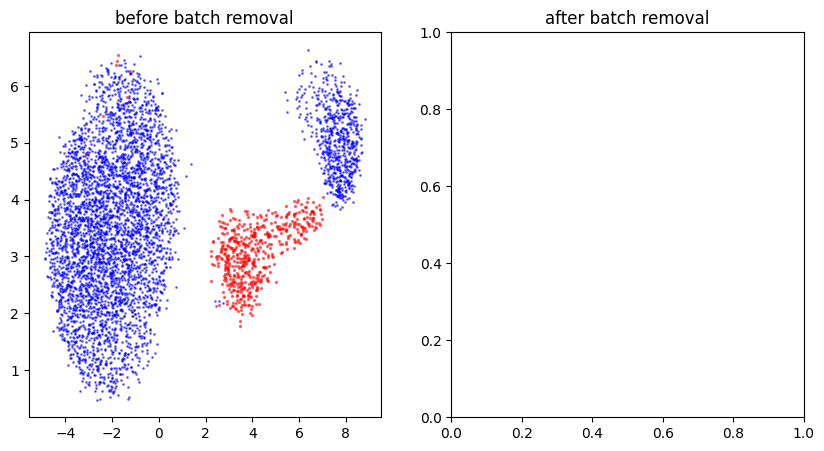

In [ ]:
ref_samp_size = ref_data.shape[0]   
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(embedding_1[:ref_samp_size, 0], embedding_1[:ref_samp_size, 1], s=1, color='blue', alpha=0.5)
ax[0].scatter(embedding_1[ref_samp_size:, 0], embedding_1[ref_samp_size:, 1], s=2, color='red', alpha=.5)
ax[1].scatter(embedding_2[:ref_samp_size, 0], embedding_2[:ref_samp_size, 1], s=1, color='blue', alpha=0.5)
ax[1].scatter(embedding_2[ref_samp_size:, 0], embedding_2[ref_samp_size:, 1], s=2, color='red', alpha=.5)
ax[0].set_title('before batch removal')
ax[1].set_title('after batch removal')
plt.show()

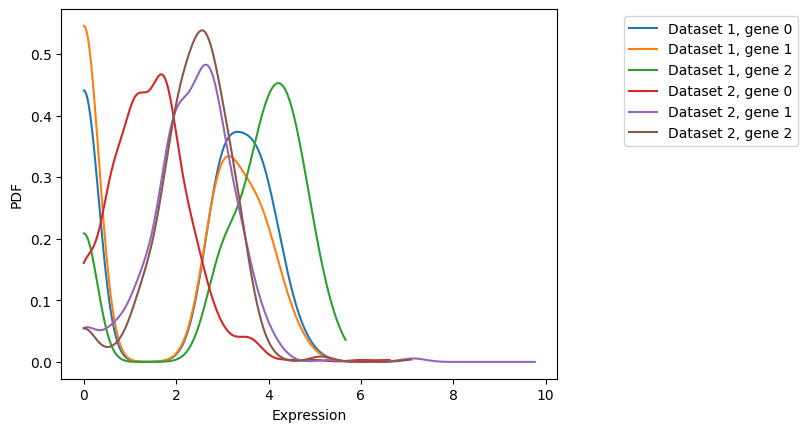

In [39]:
plt.Figure()
for i_f, file in enumerate(selected_files):
    if i_f < 1:
        adata = sc.read_h5ad(file)
        genes = adata.var.index.values
        g_index = [np.where(genes == g)[0][0] for g in hvgs]
        X = adata.X[:, g_index].toarray()
    else:
        X = corrected_data.copy()
    
    for ii in range(3):
        kde = gaussian_kde(X[:, -ii])
        x = np.linspace(min(X[:, -ii]), max(X[:, ii]), 1000)  # Generate points for x-axis
        pdf = kde(x) 
        plt.plot(x, pdf, label=f'Dataset {i_f+1}, gene {ii}')

plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.ylabel('PDF')
plt.xlabel('Expression')
plt.show()

In [40]:
# build a new dataset with the corrected data
data_ = np.concatenate((ref_data.numpy(), corrected_data), axis=0)
print(f"Number of cells in the new dataset: {data_.shape[0]}, number of genes: {data_.shape[1]}")

annos, len_data = [], []
for ff in selected_files:
    adata_ = sc.read_h5ad(ff)
    annos.append(adata_.obs)
    len_data.append(adata_.X.shape[0])
    
# mutual_keys = set.intersection(*(set(anno.keys()) for anno in annos))
mutual_keys = set.intersection(*(set(anno.keys()) for anno in annos))

# concatenate dictiornaies with common keys
mix_data = {key: np.concatenate((annos[0][key], annos[1][key]), axis=0) for key in mutual_keys}
mix_data = pd.DataFrame(mix_data)
mix_data['sample_id'] = np.concatenate((annos[0]['sample_id'], annos[1]['sample_name']), axis=0)
mix_data['external_donor_name'] = np.concatenate((annos[0]['external_donor_name'], annos[1]['exp_component_name']), axis=0)
mix_data['sex'] = np.concatenate((annos[0]['sex'], annos[1]['gender']), axis=0)
mix_data['age'] = np.concatenate((np.array([' '] * len_data[0]), annos[1]['age']), axis=0)
mix_data['batch'] = np.concatenate((annos[0]['batch'], np.array([' '] * len_data[1])), axis=0)
mix_data['injection_target'] = np.concatenate((np.array([' '] * len_data[0]), annos[1]['injection_target']), axis=0)
mix_data['dataset'] = np.concatenate((np.array(['Dbh'] * len_data[0]), np.array(['Retroseq'] * len_data[1])), axis=0)
mix_data['sex'] = np.array([s.split(';')[0] for s in mix_data['sex']])

andata_ = sc.AnnData(X=csr_matrix(data_), obs=pd.DataFrame(mix_data), var={'gene': updated_hvgs})
andata_.write(config['paths']['main_dir'] / config['paths']['data_path'] / 'Dbh_Retroseq_logcpm.h5ad')

Number of cells in the new dataset: 5133, number of genes: 1841


/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [8]:
ref_data = []
for i_f, file in enumerate([Retroseq_file]):
    adata = sc.read_h5ad(file)
    genes = adata.var.index.values
    g_index = [np.where(genes == g)[0][0] for g in updated_hvgs]
    ref_data.append(adata.X[:, g_index].toarray())

ref_data = np.vstack(ref_data)

andata = sc.read_h5ad(Dbh_file)
g_index = [np.where(andata.var.index.values == g)[0][0] for g in updated_hvgs]
query_data = andata.X[:, g_index].toarray()

np.random.shuffle(query_data)
ref_data = torch.tensor(ref_data, dtype=torch.float32)

In [24]:
# Split into 10 folds
K_fold = 20
query_folds = np.array_split(query_data, K_fold)

corrected_mtx = []
origin_query_data = []
for fold, q_data in enumerate(query_folds):
    q_tensor = torch.tensor(q_data, dtype=torch.float32) 
    corrected_mtx_ = align_query(
                                reference=ref_data, 
                                query=q_tensor,
                                neighborhood_size=20, 
                                num_anchors=100, 
                                kernel_scale=2.0, 
                                ref_batch_size = 128, 
                                query_batch_size = 128,
                                )
    print(np.isnan(corrected_mtx_).sum())
    corrected_mtx.append(corrected_mtx_)
    origin_query_data.append(q_tensor)

corrected_mtx = torch.vstack(corrected_mtx)
origin_query_data = torch.vstack(origin_query_data)
print(ref_data.shape, query_data.shape, corrected_mtx.shape, origin_query_data.shape)

Determining neighborhood...
Computing correction...    
Completed.                           
tensor(0)
Determining neighborhood...


/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/Temp/ipykernel_202730/1277956148.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(np.isnan(corrected_mtx_).sum())


Computing correction...    
Completed.                           
tensor(0)
Determining neighborhood...
Computing correction...    
Completed.                           
tensor(0)
Determining neighborhood...
Computing correction...    
Completed.                           
tensor(0)
Determining neighborhood...
Computing correction...    
Completed.                           
tensor(0)
Determining neighborhood...
Computing correction...    
Completed.                           
tensor(0)
Determining neighborhood...
Computing correction...    
Completed.                           
tensor(0)
Determining neighborhood...
Computing correction...    
Completed.                           
tensor(0)
Determining neighborhood...
Computing correction...    
Completed.                           
tensor(0)
Determining neighborhood...
Computing correction...    
Completed.                           
tensor(0)
Determining neighborhood...
Computing correction...    
Completed.                          

In [25]:
# Evaluate the alignment between AD and patchseq data
corrected_data = corrected_mtx.detach().numpy()
origin_query_data = origin_query_data.numpy()
corrected_data[corrected_data < 0] = 0.
dataset_1 = np.concatenate((ref_data, origin_query_data), axis=0)
dataset_2 = np.concatenate((ref_data, corrected_data), axis=0)
embedding_1 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=10, metric='euclidean').fit_transform(dataset_1)
embedding_2 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=10, metric='euclidean').fit_transform(dataset_2)

/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is n

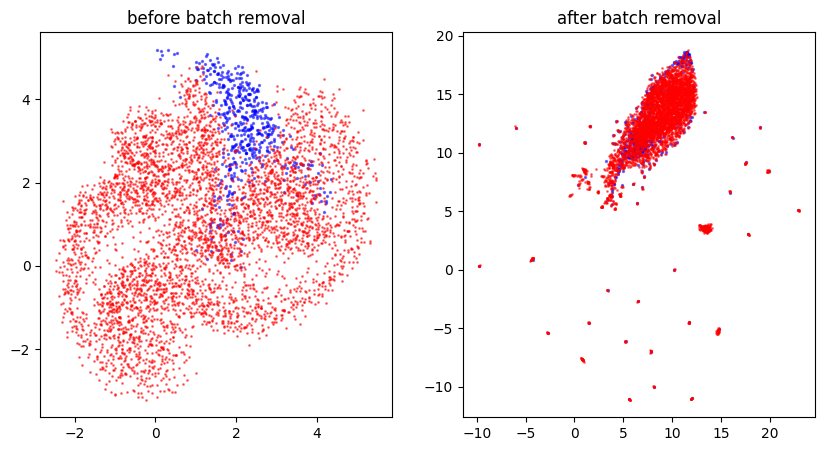

In [27]:
ref_samp_size = ref_data.shape[0]   
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(embedding_1[:ref_samp_size, 0], embedding_1[:ref_samp_size, 1], s=2, color='blue', alpha=0.5)
ax[0].scatter(embedding_1[ref_samp_size:, 0], embedding_1[ref_samp_size:, 1], s=1, color='red', alpha=.5)
ax[1].scatter(embedding_2[:ref_samp_size, 0], embedding_2[:ref_samp_size, 1], s=2, color='blue', alpha=0.5)
ax[1].scatter(embedding_2[ref_samp_size:, 0], embedding_2[ref_samp_size:, 1], s=1, color='red', alpha=.5)
ax[0].set_title('before batch removal')
ax[1].set_title('after batch removal')
plt.show()

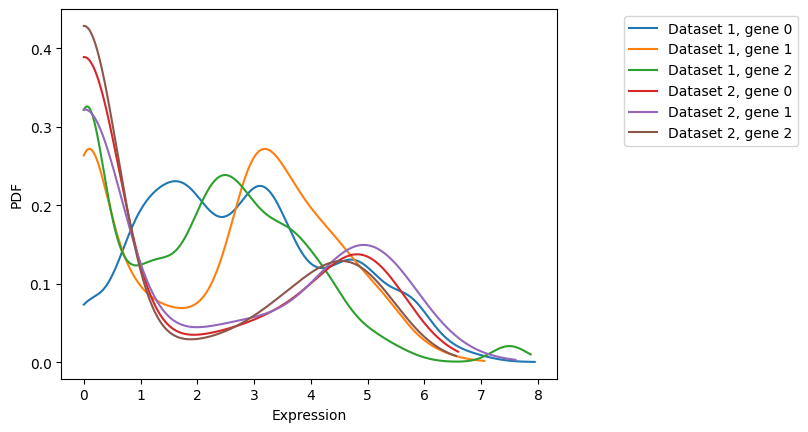

In [28]:
plt.Figure()
for i_f, file in enumerate(selected_files):
    if i_f ==0 :
        X = corrected_data.copy()
    else:
        adata = sc.read_h5ad(file)
        genes = adata.var.index.values
        g_index = [np.where(genes == g)[0][0] for g in hvgs]
        X = adata.X[:, g_index].toarray()
    
    for ii in range(3):
        kde = gaussian_kde(X[:, -ii])
        x = np.linspace(min(X[:, -ii]), max(X[:, ii]), 1000)  # Generate points for x-axis
        pdf = kde(x) 
        plt.plot(x, pdf, label=f'Dataset {i_f+1}, gene {ii}')

plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.ylabel('PDF')
plt.xlabel('Expression')
plt.show()

In [29]:
# build a new dataset with the corrected data
data_ = np.concatenate((corrected_data, ref_data.numpy()), axis=0)
print(f"Number of cells in the new dataset: {data_.shape[0]}, number of genes: {data_.shape[1]}")

annos, len_data = [], []
for ff in selected_files:
    adata_ = sc.read_h5ad(ff)
    annos.append(adata_.obs)
    len_data.append(adata_.X.shape[0])
    
# mutual_keys = set.intersection(*(set(anno.keys()) for anno in annos))
mutual_keys = set.intersection(*(set(anno.keys()) for anno in annos))

# concatenate dictiornaies with common keys
mix_data = {key: np.concatenate((annos[0][key], annos[1][key]), axis=0) for key in mutual_keys}
mix_data = pd.DataFrame(mix_data)
mix_data['sample_id'] = np.concatenate((annos[0]['sample_id'], annos[1]['sample_name']), axis=0)
mix_data['external_donor_name'] = np.concatenate((annos[0]['external_donor_name'], annos[1]['exp_component_name']), axis=0)
mix_data['sex'] = np.concatenate((annos[0]['sex'], annos[1]['gender']), axis=0)
mix_data['age'] = np.concatenate((np.array([' '] * len_data[0]), annos[1]['age']), axis=0)
mix_data['batch'] = np.concatenate((annos[0]['batch'], np.array([' '] * len_data[1])), axis=0)
mix_data['injection_target'] = np.concatenate((np.array([' '] * len_data[0]), annos[1]['injection_target']), axis=0)
mix_data['dataset'] = np.concatenate((np.array(['Dbh'] * len_data[0]), np.array(['Retroseq'] * len_data[1])), axis=0)
mix_data['sex'] = np.array([s.split(';')[0] for s in mix_data['sex']])

andata_ = sc.AnnData(X=csr_matrix(data_), obs=pd.DataFrame(mix_data), var={'gene': updated_hvgs})
andata_.write(config['paths']['main_dir'] / config['paths']['data_path'] / 'Retroseq_Dbh_logcpm.h5ad')

Number of cells in the new dataset: 5133, number of genes: 1841


/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [26]:
ref_data = []
for i_f, file in enumerate([Dbh_file]):
    adata = sc.read_h5ad(file)
    genes = adata.var.index.values
    g_index = [np.where(genes == g)[0][0] for g in updated_hvgs]
    x = adata.X[:, g_index].toarray()
    scaler = StandardScaler()
    ref_data.append(scaler.fit_transform(x))

ref_data = np.vstack(ref_data)

andata = sc.read_h5ad(Retroseq_file)
g_index = [np.where(andata.var.index.values == g)[0][0] for g in updated_hvgs]
x = andata.X[:, g_index].toarray()
scaler = StandardScaler()
query_data = scaler.fit_transform(x)


In [27]:
# convert data to torch
ref_data = torch.tensor(ref_data, dtype=torch.float32)
query_data = torch.tensor(query_data, dtype=torch.float32)
# Remove batch effect between AD and patchseq data
corrected_mtx = align_query(
                            reference=ref_data, 
                            query=query_data, 
                            neighborhood_size=250, 
                            num_anchors=5, 
                            kernel_scale=5.0, 
                            ref_batch_size = 1024, 
                            query_batch_size = 64,
                            )
print(np.isnan(corrected_mtx).sum())

Determining neighborhood...
Computing correction...      
Completed.                           
tensor(0)


/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/Temp/ipykernel_18009/782754017.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(np.isnan(corrected_mtx).sum())


In [28]:
# Evaluate the alignment between AD and patchseq data
corrected_data = corrected_mtx.detach().numpy()
dataset_1 = np.concatenate((ref_data.numpy(), query_data.numpy()), axis=0)
dataset_2 = np.concatenate((ref_data.numpy(), corrected_data), axis=0)
embedding_1 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=10, metric='euclidean').fit_transform(dataset_1)
embedding_2 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=10, metric='euclidean').fit_transform(dataset_2)

/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


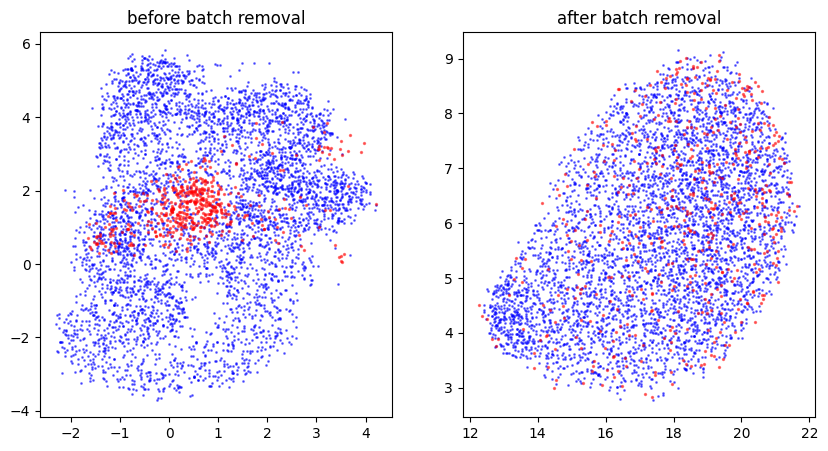

In [29]:
ref_samp_size = ref_data.shape[0]   
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(embedding_1[:ref_samp_size, 0], embedding_1[:ref_samp_size, 1], s=1, color='blue', alpha=0.5)
ax[0].scatter(embedding_1[ref_samp_size:, 0], embedding_1[ref_samp_size:, 1], s=2, color='red', alpha=.5)
ax[1].scatter(embedding_2[:ref_samp_size, 0], embedding_2[:ref_samp_size, 1], s=1, color='blue', alpha=0.5)
ax[1].scatter(embedding_2[ref_samp_size:, 0], embedding_2[ref_samp_size:, 1], s=2, color='red', alpha=.5)
ax[0].set_title('before batch removal')
ax[1].set_title('after batch removal')
plt.show()

In [33]:
corrected_data[0, :]

array([ 0.20417905,  0.52889603,  0.5785724 , ...,  0.32483977,
        0.95420593, -0.07594049], dtype=float32)

In [34]:
query_data[0, :]

tensor([ 0.9611,  0.0744,  0.3010,  ...,  1.1363,  0.4288, -1.1356])

4.2414767457968856e-14
259.1946


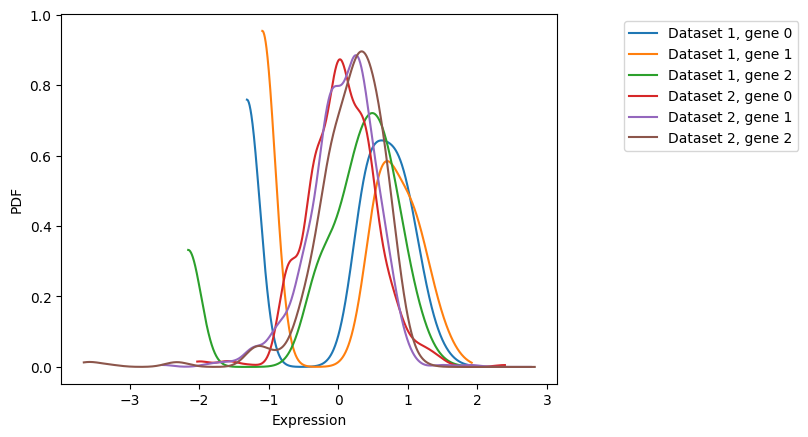

In [32]:
plt.Figure()
for i_f, file in enumerate(selected_files):
    if i_f < 1:
        adata = sc.read_h5ad(file)
        genes = adata.var.index.values
        g_index = [np.where(genes == g)[0][0] for g in hvgs]
        x = adata.X[:, g_index].toarray()
        scaler = StandardScaler()
        X = scaler.fit_transform(x)
    else:
        X = corrected_data.copy()
    
    print(np.sum(np.mean(X, axis=0)))
    for ii in range(3):
        kde = gaussian_kde(X[:, -ii])
        x = np.linspace(min(X[:, -ii]), max(X[:, ii]), 1000)  # Generate points for x-axis
        pdf = kde(x) 
        plt.plot(x, pdf, label=f'Dataset {i_f+1}, gene {ii}')

plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.ylabel('PDF')
plt.xlabel('Expression')
plt.show()

In [33]:
# build a new dataset with the corrected data
data_ = np.concatenate((ref_data.numpy(), corrected_data), axis=0)
print(f"Number of cells in the new dataset: {data_.shape[0]}, number of genes: {data_.shape[1]}")

annos, len_data = [], []
for ff in selected_files:
    adata_ = sc.read_h5ad(ff)
    annos.append(adata_.obs)
    len_data.append(adata_.X.shape[0])
    
# mutual_keys = set.intersection(*(set(anno.keys()) for anno in annos))
mutual_keys = set.intersection(*(set(anno.keys()) for anno in annos))

# concatenate dictiornaies with common keys
mix_data = {key: np.concatenate((annos[0][key], annos[1][key]), axis=0) for key in mutual_keys}
mix_data = pd.DataFrame(mix_data)
mix_data['sample_id'] = np.concatenate((annos[0]['sample_id'], annos[1]['sample_name']), axis=0)
mix_data['external_donor_name'] = np.concatenate((annos[0]['external_donor_name'], annos[1]['exp_component_name']), axis=0)
mix_data['sex'] = np.concatenate((annos[0]['sex'], annos[1]['gender']), axis=0)
mix_data['age'] = np.concatenate((np.array([' '] * len_data[0]), annos[1]['age']), axis=0)
mix_data['batch'] = np.concatenate((annos[0]['batch'], np.array([' '] * len_data[1])), axis=0)
mix_data['injection_target'] = np.concatenate((np.array([' '] * len_data[0]), annos[1]['injection_target']), axis=0)
mix_data['dataset'] = np.concatenate((np.array(['Dbh'] * len_data[0]), np.array(['Retroseq'] * len_data[1])), axis=0)
mix_data['sex'] = np.array([s.split(';')[0] for s in mix_data['sex']])

andata_ = sc.AnnData(X=csr_matrix(data_), obs=pd.DataFrame(mix_data), var={'gene': updated_hvgs})
andata_.write(config['paths']['main_dir'] / config['paths']['data_path'] / 'Dbh_Retroseq_logcpm.h5ad')

Number of cells in the new dataset: 5133, number of genes: 1841


/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
